Execute a preparação antes de começar. Ela baixa uma imagem e as funções de
visualização do repositório público. As operações que vamos estudar aparecem
nas células seguintes. No Colab, use um ambiente Python com PyTorch e TorchVision.

In [1]:
from urllib.request import urlretrieve
base = "https://raw.githubusercontent.com/carlosfab/bootcamp-visao-computacional-drones/5ac553c9376821eb182306d716d3553bb7db2e48/"
urlretrieve(base + "dados/aula-02/praca-sintetica.png", "praca.png")
urlretrieve(base + "apoio/aula02.py", "apoio.py");

In [2]:
import torch
from PIL import Image
from torchvision.transforms.functional import pil_to_tensor
from apoio import mostrar, mostrar_caixas, varredura

Observe a cena. Quais categorias aparecem? Onde está **cada objeto**?

A imagem foi gerada por IA para esta demonstração. Vamos trabalhar com uma
cópia de 768 × 512 pixels. Ela não é uma fotografia de voo nem um conjunto de avaliação.

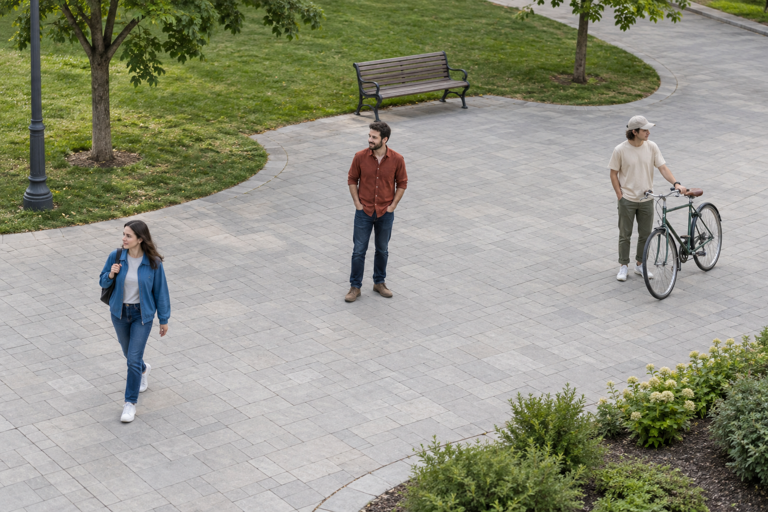

In [3]:
foto = Image.open("praca.png").convert("RGB")
foto = foto.resize((768, 512))
foto

Uma classificação pode informar a categoria de uma imagem ou de um recorte.
Na detecção, queremos também **localizar as instâncias**. Três pessoas da mesma
categoria precisam de três localizações.

Vamos representar a imagem como tensor. `pil_to_tensor` conserva os valores
inteiros e coloca os canais no primeiro eixo: `[C, H, W]`.

In [4]:
imagem = pil_to_tensor(foto)
imagem.shape, imagem.dtype

(torch.Size([3, 512, 768]), torch.uint8)

Escolha uma pessoa. Uma caixa retangular pode ser escrita como
`[x_min, y_min, x_max, y_max]`. A origem está no canto superior esquerdo:
`x` cresce para a direita e `y`, para baixo.

Os números abaixo delimitam aproximadamente a pessoa do centro.
São coordenadas escolhidas manualmente, não uma previsão ou uma anotação oficial.

In [5]:
x1, y1, x2, y2 = 340, 115, 410, 310
caixa = torch.tensor([[x1, y1, x2, y2]])
caixa

tensor([[340, 115, 410, 310]])

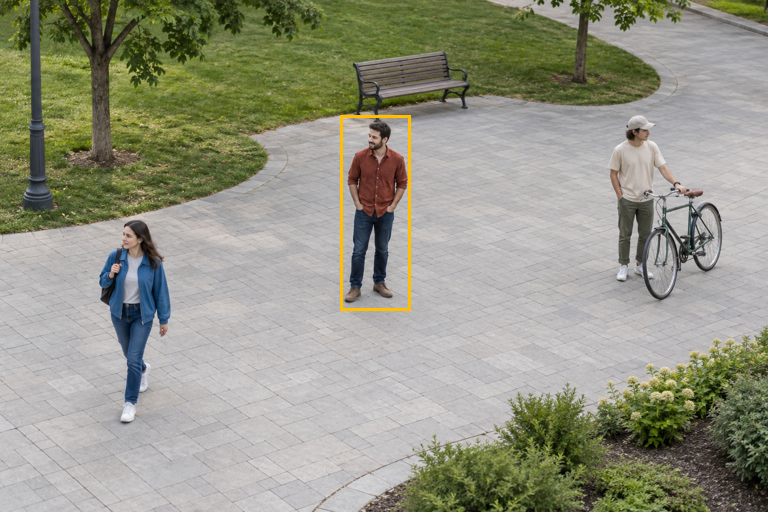

In [6]:
mostrar_caixas(imagem, caixa)

A caixa tem quatro coordenadas, mas o recorte é indexado por **linhas e colunas**:
`imagem[canais, y, x]`. O limite final de cada intervalo é excluído.
Antes de executar, preveja a altura e a largura do recorte.

In [7]:
recorte = imagem[:, y1:y2, x1:x2]
recorte.shape

torch.Size([3, 195, 70])

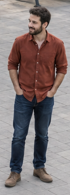

In [8]:
mostrar(recorte)

Agora a região será uma janela quadrada. Vamos mudar sua posição manualmente.
A janela pode conter uma pessoa, uma parte dela ou apenas o chão.

In [9]:
x, y = 288, 96
janela = 192
recorte = imagem[:, y:y + janela, x:x + janela]

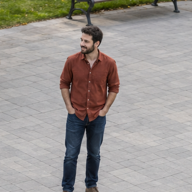

In [10]:
mostrar(recorte)

Se tivéssemos um classificador de recortes, uma ideia seria analisar muitas
posições da imagem. Esta animação mostra **somente a busca por regiões**:
ela move uma janela e exibe o recorte correspondente, sem classificar nada.

Clique em reproduzir ou avance quadro a quadro. O `passo` indica o deslocamento
entre posições; na última posição de cada eixo a janela é alinhada à borda.

In [11]:
varredura(imagem, janela=192, passo=96)

Experimente `passo=192` e depois retorne a `96`. O que muda na sobreposição
e na quantidade de recortes? Em seguida, altere apenas `janela` para `256`.

Uma janela pequena pode cortar o objeto. Uma janela grande inclui mais contexto.
Mais recortes aumentam o trabalho de uma estratégia que classifique cada recorte.
Nenhuma dessas janelas é, por si só, uma caixa detectada.

Detectores podem compartilhar o cálculo das características da imagem.
A varredura acima é uma construção didática; não descreve o processamento
literal de todo detector atual.

| Organização | Ideia central | Exemplo |
|---|---|---|
| Duas etapas | Propor regiões e depois classificar/refinar essas regiões | Faster R-CNN |
| Uma etapa | Predizer classes e caixas em posições dos mapas de características, sem essa etapa separada de propostas | FCOS |

As etapas do Faster R-CNN compartilham características. Uma etapa não significa
uma única camada nem ausência de pós-processamento. Essa distinção não estabelece
uma regra universal de velocidade ou precisão.

Vamos executar um detector já treinado. O exemplo usa Faster R-CNN com backbone
ResNet-50 e FPN, com pesos `COCO_V1`. O nome identifica a arquitetura e os pesos
utilizados; não significa que treinaremos a rede nesta prática.

**Preparação:** a primeira execução baixa aproximadamente 167 MiB de pesos.
Execute esse trecho antes da exposição. GPU é opcional; a inferência em CPU é mais lenta.

In [12]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_V2_Weights as Pesos

In [13]:
pesos = Pesos.COCO_V1
modelo = fasterrcnn_resnet50_fpn_v2(weights=pesos)

O pré-processamento acompanha os pesos. Aqui ele converte a imagem para ponto
flutuante em `[0, 1]`. O detector também aplica transformações internas,
incluindo redimensionamento; não devemos repetir manualmente uma normalização
genérica de outro modelo.

In [14]:
preparar = pesos.transforms()
entrada = preparar(foto)
entrada.shape, entrada.dtype

(torch.Size([3, 512, 768]), torch.float32)

In [15]:
entrada.min(), entrada.max()

(tensor(0.), tensor(0.9804))

Modelo e entrada precisam estar no mesmo dispositivo. No Colab, `cuda` é usado
quando há uma GPU compatível habilitada; caso contrário, a execução segue na CPU.

In [16]:
dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
modelo = modelo.to(dispositivo)
entrada = entrada.to(dispositivo)

`eval()` coloca o modelo em modo de avaliação. `inference_mode()` desativa o
registro de gradientes para esta inferência. São duas responsabilidades diferentes.

Este detector recebe uma **lista de imagens**, cada uma com formato `[C, H, W]`.
`[entrada]` é uma lista com uma imagem, e `[0]` seleciona o resultado dessa imagem.

In [17]:
modelo.eval()
with torch.inference_mode():
    saida = modelo([entrada])[0]

In [18]:
saida.keys()

dict_keys(['boxes', 'labels', 'scores'])

Cada posição dos três tensores se refere à mesma detecção:
`boxes` contém a caixa, `labels` contém o identificador da classe e `scores`
contém o score. As caixas retornadas estão nas coordenadas da imagem fornecida.
Essa saída já passou pelo pós-processamento interno do detector.

In [19]:
saida["boxes"].shape, saida["labels"].shape, saida["scores"].shape

(torch.Size([15, 4]), torch.Size([15]), torch.Size([15]))

In [20]:
saida["boxes"][:3]

tensor([[606.0085, 113.4281, 697.1356, 282.0586],
        [ 97.8122, 221.8026, 170.9090, 422.9864],
        [344.0987, 119.9799, 409.0773, 302.9692]])

In [21]:
saida["labels"][:3], saida["scores"][:3]

(tensor([1, 1, 1]), tensor([0.9998, 0.9997, 0.9993]))

Os nomes das classes fazem parte dos metadados dos pesos. Vamos interpretar
a primeira previsão. Ela pode ser correta ou incorreta; confira a imagem.

In [22]:
categorias = pesos.meta["categories"]
categorias[saida["labels"][0].item()] if len(saida["labels"]) else "Sem detecções"

'person'

Um limiar permite selecionar as previsões que vamos exibir. Esse filtro
não modifica os pesos nem executa a rede outra vez. O score não deve ser
interpretado automaticamente como probabilidade calibrada de acerto.

In [23]:
limiar = 0.5
manter = saida["scores"] >= limiar
manter.sum().item()

6

In [24]:
caixas = saida["boxes"][manter].cpu()
classes = saida["labels"][manter].cpu()
scores = saida["scores"][manter].cpu()

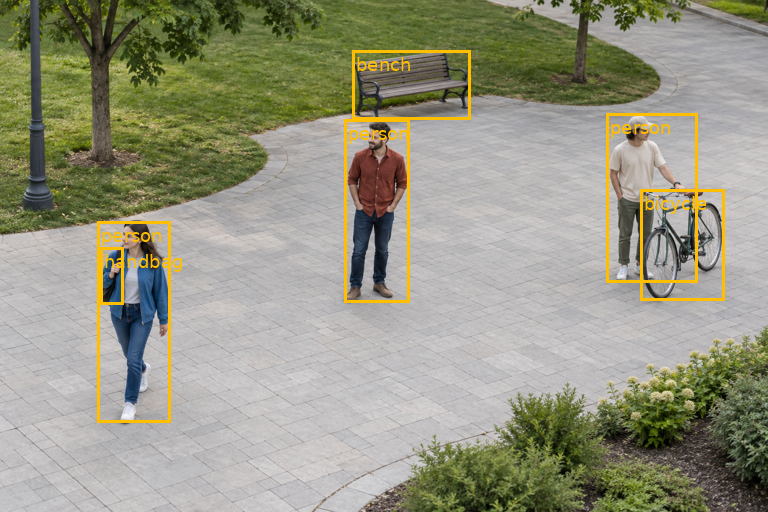

In [25]:
rotulos = [categorias[classe.item()] for classe in classes]
mostrar_caixas(imagem, caixas, rotulos)

Vamos associar o score a cada nome. As três listas/tensores continuam na mesma ordem.

In [26]:
for nome, score in zip(rotulos, scores):
    print(nome, round(score.item(), 3))

person 1.0
person 1.0
person 0.999
bench 0.999
bicycle 0.998
handbag 0.882


Altere somente o limiar para `0.9` e execute novamente as quatro células de
seleção e exibição acima. Quais previsões saíram? Alguma pessoa deixou de aparecer?
Depois retorne a `0.5`.

Uma caixa desenhada manualmente, uma janela de busca e uma caixa prevista têm
o mesmo formato geométrico, mas origens e funções diferentes. Explique essa
diferença usando as três saídas que acabamos de observar.

Para imagens de drone, o próximo teste precisa considerar objetos menores,
novos pontos de vista e outros cenários. Este exemplo sintético demonstra a
interface e a interpretação das previsões, não valida o desempenho em voos reais.

Referências para consulta:

- [TorchVision: Faster R-CNN com ResNet-50 FPN v2](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.detection.fasterrcnn_resnet50_fpn_v2.html)
- [TorchVision: entrada e saída dos detectores](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.detection.fasterrcnn_resnet50_fpn.html)
- [Faster R-CNN: artigo original](https://arxiv.org/abs/1506.01497)
- [FCOS: artigo original](https://arxiv.org/abs/1904.01355)
- [Matplotlib: animação incorporada em HTML](https://matplotlib.org/stable/api/_as_gen/matplotlib.animation.Animation.html#matplotlib.animation.Animation.to_jshtml)